# Which Statistics Drive Winning in European Football? – Modeling & Evaluation

This notebook aims to build and evaluate machine learning models to predict match outcomes in European football using the feature-engineered match statistics created in the previous notebook. A binary target variable representing whether the home team won the match is used as the outcome of interest.

The following steps are performed in this notebook:

- **Features**: Differential match statistics such as expected goals difference, possession difference, shots on target difference, corners difference, and passes difference  
- **Target Variable**: Match outcome (home win vs. non-home win)  
- **Models**: Baseline and comparative classification models  
- **Evaluation**: Model performance assessed using standard classification metrics  

The output of this notebook is an evaluation of how well match-level performance statistics explain winning outcomes, along with insights into which features are most influential in predicting match results across Europe’s top football leagues.


In [381]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load feature-engineered dataset
df = pd.read_csv("../data/football_2023_2024_features.csv")

# Remove rows with missing values
df = df.dropna()

print("Shape:", df.shape)
df.head()


Shape: (989, 20)


,League,home_goals,away_goals,season_year,xg_home,xg_away,possession_home,possession_away,shots_on_target_home,shots_on_target_away,corners_home,corners_away,passes_home,passes_away,home_win,xg_diff,possession_diff,shots_on_target_diff,corners_diff,passes_diff
0,Bundesliga,0,4,2023/2024,1.94,2.76,42.0,58.0,5.0,8.0,14.0,8.0,363.0,703.0,0,-0.82,-16.0,-3.0,6.0,-340.0
1,Bundesliga,0,3,2023/2024,1.32,2.25,55.0,45.0,3.0,8.0,7.0,8.0,482.0,313.0,0,-0.93,10.0,-5.0,-1.0,169.0
2,Bundesliga,2,1,2023/2024,2.86,0.77,62.0,38.0,8.0,2.0,5.0,4.0,728.0,382.0,1,2.09,24.0,6.0,1.0,346.0
3,Bundesliga,4,0,2023/2024,2.83,0.42,71.0,29.0,10.0,1.0,7.0,3.0,727.0,258.0,1,2.41,42.0,9.0,4.0,469.0
4,Bundesliga,2,2,2023/2024,2.02,1.73,46.0,54.0,6.0,5.0,8.0,3.0,432.0,520.0,0,0.29,-8.0,1.0,5.0,-88.0


This step defines the feature matrix using differential match statistics and sets the target variable as a binary indicator of a home team win.

In [382]:
# Defining the feature matrix (X) and Target (y)

X = df[
    ["xg_diff", "possession_diff", "shots_on_target_diff",
     "corners_diff", "passes_diff"]
]
y = df["home_win"]

print("X Shape: ", X.shape)
print("y Shape: ", y.shape)

X Shape:  (989, 5)
y Shape:  (989,)


This step defines the feature matrix using differential match statistics and sets the target variable as a binary indicator of a home team win.

In [383]:
# Train test split (75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Sanity checks
print("Total rows:", len(X))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training %:", len(X_train) / len(X))
print("Testing %:", len(X_test) / len(X))

# Checking how balanced the class is
print("Overall home win rate:", y.mean())
print("Train home win rate:", y_train.mean())
print("Test home win rate:", y_test.mean())


Total rows: 989
Training rows: 741
Testing rows: 248
Training %: 0.7492416582406471
Testing %: 0.25075834175935285
Overall home win rate: 0.43377148634984836
Train home win rate: 0.4331983805668016
Test home win rate: 0.43548387096774194


This step initializes a baseline logistic regression model to learn the relationship between match statistics and the probability of a home win.

In [384]:
from sklearn.linear_model import LogisticRegression

# Initialize baseline logistic regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42     
)

In [385]:
# Train the model on the training data
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

This section generates predictions from the trained logistic regression model and evaluates baseline performance using standard classification metrics.

In [386]:
# Generate predictions on the test set

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7701612903225806
ROC-AUC: 0.8294312169312169

Confusion Matrix:
[[103  37]
 [ 20  88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.78       140
           1       0.70      0.81      0.76       108

    accuracy                           0.77       248
   macro avg       0.77      0.78      0.77       248
weighted avg       0.78      0.77      0.77       248



## Feature Importance Interpretation

The largest positive coefficients indicate which match statistics most strongly increase the probability of a home win.

The largest negative coefficients indicate which statistics are associated with the away team having an advantage.

Features with larger absolute coefficient values have a stronger impact on the model's predictions.

In [387]:
leagues = {
    "Premier League": df[df["League"] == "Premier-league"],
    "Bundesliga": df[df["League"] == "Bundesliga"],
    "Ligue 1": df[df["League"] == "Ligue-1"]
}

This function trains a logistic regression model on a given league subset, evaluates performance, and returns both model metrics and feature importance coefficients.

In [388]:
from sklearn.metrics import accuracy_score, roc_auc_score

def train_log_reg(df_subset):
    X = df_subset[["xg_diff", "possession_diff", "shots_on_target_diff", "corners_diff", "passes_diff"]]
    y = df_subset["home_win"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_[0]
    })

    coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="Absolute_Coefficient", ascending=False)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    return coef_df, acc, auc

The model is applied separately to each league, storing performance metrics and feature importance results for comparison.

In [389]:
results = {}

for league_name, df_league in leagues.items():
    coef_df, acc, auc = train_log_reg(df_league)
    results[league_name] = {
        "coefficients": coef_df,
        "accuracy": acc,
        "auc": auc
    }

Results are displayed for each league, including accuracy, ROC-AUC, and ranked feature importance based on coefficient magnitude.

In [390]:
for league_name, result in results.items():
    print(f"{league_name}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"ROC-AUC: {result['auc']:.3f}")
    print(result["coefficients"])

Premier League
Accuracy: 0.758
ROC-AUC: 0.839
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     0.856064              0.856064
2  shots_on_target_diff     0.253908              0.253908
3          corners_diff    -0.092438              0.092438
1       possession_diff    -0.088808              0.088808
4           passes_diff     0.009335              0.009335
Bundesliga
Accuracy: 0.697
ROC-AUC: 0.788
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     0.744653              0.744653
2  shots_on_target_diff     0.216061              0.216061
3          corners_diff    -0.147518              0.147518
1       possession_diff     0.009458              0.009458
4           passes_diff    -0.001435              0.001435
Ligue 1
Accuracy: 0.805
ROC-AUC: 0.888
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     1.011965              1.011965
2  shots_on_target_diff     0.261340           

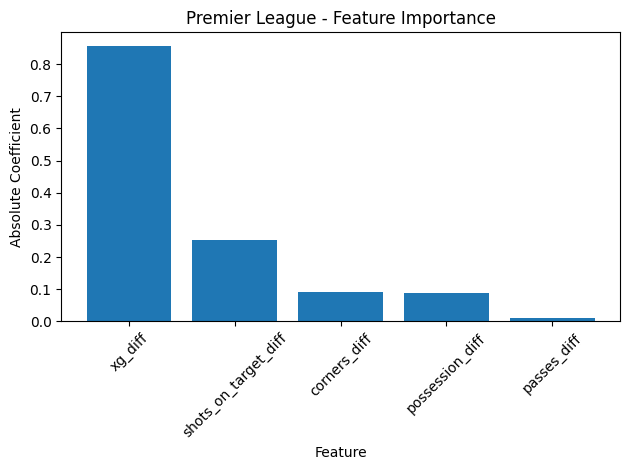

In [ ]:
import matplotlib.pyplot as plt

for league_name, result in results.items():
    coef_df = result["coefficients"]

    plt.figure()
    plt.bar(coef_df["Feature"], coef_df["Absolute_Coefficient"])
    plt.title(f"{league_name} - Feature Importance")
    plt.xlabel("Feature")
    plt.ylabel("Absolute Coefficient")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

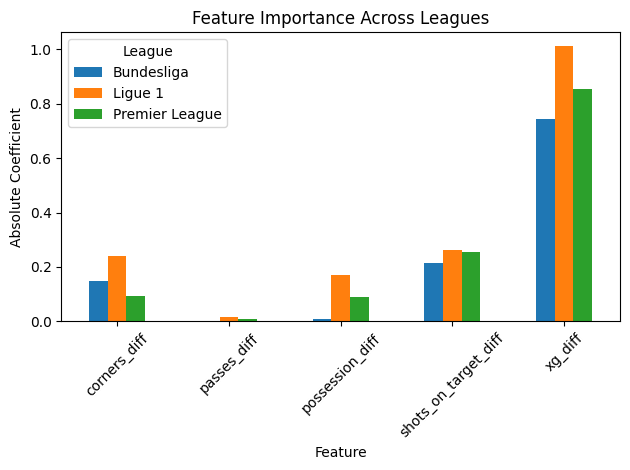

In [ ]:
import pandas as pd

combined = []

for league_name, result in results.items():
    temp = result["coefficients"].copy()
    temp["League"] = league_name
    combined.append(temp)

combined_df = pd.concat(combined)

pivot_df = combined_df.pivot(index="Feature", columns="League", values="Absolute_Coefficient")

pivot_df.plot(kind="bar")
plt.title("Feature Importance Across Leagues")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Robustness Check: Model Complexity

In [ ]:
# Random Forest Model Comparison

from sklearn.ensemble import RandomForestClassifier

rf_results = {}

for league_name, df_league in leagues.items():
    
    X = df_league[["xg_diff", "possession_diff", "shots_on_target_diff", "corners_diff", "passes_diff"]]
    y = df_league["home_win"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    rf_results[league_name] = {
        "accuracy": acc,
        "auc": auc
    }

# Print comparison
print("Random Forest Results")
for league_name, result in rf_results.items():
    print(f"\n{league_name}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"ROC-AUC: {result['auc']:.3f}")

Random Forest Results

Premier League
Accuracy: 0.705
ROC-AUC: 0.776

Bundesliga
Accuracy: 0.737
ROC-AUC: 0.796

Ligue 1
Accuracy: 0.727
ROC-AUC: 0.803


To further validate the patterns observed in the feature importance analysis, a Random Forest classifier was trained using the same feature set.

Random Forest is a tree-based ensemble model that can capture non-linear relationships and interactions between features. Unlike logistic regression, which assumes a linear relationship between inputs and the probability of a home win, Random Forest can model more complex patterns without requiring explicit feature engineering. This makes it useful for testing whether important relationships may have been missed by a simpler model.

Across all three leagues, the Random Forest model performed slightly worse than logistic regression in both accuracy and ROC-AUC. This suggests that the relationship between match statistics and outcomes is relatively simple and does not benefit from more complex modeling.

As a result, logistic regression is sufficient for this analysis and remains preferable due to its interpretability, allowing for clear insight into which statistics drive winning.

## Key Insights Across Leagues

The modeling results, along with the feature importance visualization above, reveal several consistent patterns in how match statistics relate to winning outcomes, as well as key differences across leagues:

- **Ligue 1 is the most predictable league**, achieving the highest accuracy and ROC-AUC. As seen in both the model performance metrics and the graph, this suggests that match outcomes are more strongly driven by measurable performance differences. One possible explanation is lower parity between teams, where stronger teams more consistently outperform weaker ones.

- **Expected goals difference (xg_diff) is the dominant predictor across all leagues**, with the largest coefficient by a clear margin. This is clearly visible in the graph, where xg_diff consistently has the highest importance across all three leagues. This consistency across leagues suggests that chance quality is a universal driver of match outcomes.

- **Shots on target difference is consistently the second most important feature across all leagues**, as shown in the graph. While it has a strong relationship with winning, its impact is noticeably lower than xg_diff in every league. This highlights that shot volume alone is not as informative as the quality of chances created.

- **The relative importance of attacking metrics is consistent across leagues**, with both xg_diff and shots on target clearly standing out above all other features. This similarity suggests that offensive performance is the primary determinant of success regardless of league.

- **Possession shows variation across leagues**, with a weaker or near-zero coefficient in the Bundesliga compared to the other leagues. This indicates low predictive power in that context and may reflect a more direct or transition-oriented style of play in the Bundesliga, where controlling possession is less critical to winning.

- **Pass difference is consistently the least important feature across all leagues**, with coefficients close to zero. This indicates minimal contribution to the model’s predictions and suggests that higher passing volume does not meaningfully contribute to predicting match outcomes in any league.

- **Control-based metrics such as possession and passing are consistently less important than attacking metrics**, which is evident in all three leagues. This suggests that maintaining control of the ball does not necessarily translate into effective performance or winning.

- **Ligue 1 shows the strongest dependence on xg_diff**, with a noticeably higher coefficient compared to the other leagues. This suggests that statistical advantages translate more directly into results in Ligue 1 than in the other leagues.

- **Bundesliga appears to be the least predictable league**, with the lowest accuracy and ROC-AUC. This indicates weaker separability between winning and non-winning outcomes using the selected features. In addition, the feature importance values are more evenly distributed compared to the other leagues, suggesting that outcomes may be influenced by a wider range of factors.

- **The Premier League falls between Ligue 1 and Bundesliga in both predictability and feature importance distribution**, indicating a balance between structured, performance-driven outcomes and variability. This is reflected in both its performance metrics and the relative spread of feature importance values in the graph.

## Playstyle Differences and Similarities

While the model does not directly include tactical or stylistic variables, the relative importance of different match statistics provides insight into how playstyles may differ across leagues.

- **Attacking efficiency is the dominant factor across all leagues**, as shown by the consistent importance of xg_diff and shots on target. This suggests that regardless of league, teams that create higher quality chances are more likely to win. This is a clear similarity across all three leagues.

- **Ligue 1 appears more performance-driven**, with a stronger reliance on xg_diff and higher overall predictability. This may indicate a more structured style of play, where matches are more consistently decided by measurable differences in attacking output.

- **Bundesliga shows signs of a more variable or open style of play**, with lower model performance and a more even distribution of feature importance. The weaker relationship between possession and winning suggests that teams may rely more on transitions and quick attacking sequences rather than sustained control.

- **The Premier League reflects a balance between structure and variability**, with strong importance for attacking metrics but less dominance compared to Ligue 1. This suggests a mix of playstyles, where both structured buildup and transition-based play can be effective.

- **Possession and passing have limited importance across all leagues**, indicating that controlling the ball has low predictive power in this model. This challenges the assumption that possession-heavy playstyles are inherently more effective and suggests that how possession is used is more important than how much of it a team has.

Overall, while attacking quality is a universal driver of success, the degree to which statistical performance translates into outcomes differs across leagues. This points to subtle but meaningful differences in how matches are played and decided.

## Limitations of the Analysis

While the results provide useful insight into how match statistics relate to outcomes, there are several limitations to consider:

- **The model uses in-match statistics**, meaning the analysis is primarily explanatory rather than predictive. Features such as expected goals and shots on target are recorded during the match, so the model is identifying relationships that occur alongside the outcome rather than forecasting it in advance.

- **The feature set is limited to a small number of statistics**, and does not include other potentially important factors such as team strength, player quality, injuries, or tactical decisions. These factors may also influence match outcomes but are not captured in the current model.

- **League-level differences may be influenced by sample size and data quality**, particularly since only three leagues are included in the analysis. Results may change if additional leagues or seasons are incorporated.

- **Some features may reflect correlation rather than causation**, especially metrics like possession and corners. For example, teams that are losing may accumulate more corners or possession while attempting to recover, which can weaken their apparent relationship with winning.

- **The model assumes a consistent relationship between features and outcomes within each league**, which may not fully capture variations in playstyle between teams or across different match contexts.

- **Simplification through differential features (home minus away)** reduces complexity but may omit important nuances, such as absolute performance levels or situational factors during a match.

Overall, while the analysis identifies meaningful patterns in the data, the results should be interpreted as indicative rather than definitive explanations of match outcomes.

## Model Comparison: Logistic Regression vs Random Forest

To evaluate whether more complex models improve performance, a Random Forest classifier was trained on the same feature set and compared against the baseline logistic regression model.

Across all three leagues, the Random Forest model performed slightly worse than logistic regression. In the Premier League, accuracy dropped from approximately 0.76 to 0.71 and ROC-AUC from 0.84 to 0.78. A similar pattern is observed in the Bundesliga and Ligue 1, where Random Forest shows lower or comparable performance across both metrics.

This result suggests that the relationship between match statistics and outcomes is relatively simple and largely linear. The selected features, particularly xg_diff and shots_on_target_diff, appear to capture most of the predictive signal without requiring more complex, non-linear modeling techniques.

Additionally, the lower performance of Random Forest may be influenced by the relatively small dataset size and limited number of features. Tree-based models typically benefit from larger datasets and more complex feature interactions, which are not strongly present in this analysis.

Overall, these findings reinforce that logistic regression is not only sufficient but preferable in this context, as it provides strong performance while remaining highly interpretable. This is particularly valuable given the goal of understanding which statistics drive winning, rather than maximizing predictive accuracy alone.

## Future Improvements

There are several ways this analysis could be extended or improved in future work:

- **Incorporate pre-match features**, such as team strength ratings, recent form, or betting odds, to shift the model from explanatory analysis toward true predictive modeling.

- **Expand the dataset across multiple seasons and additional leagues**, which would improve robustness and allow for more reliable comparisons of playstyle and predictability.

- **Explore more advanced models and validation techniques**, such as tree-based models or cross-validation, to better capture non-linear relationships and ensure the stability of results.


## Conclusion

This analysis confirms that attacking performance, particularly expected goals and shots on target, is the strongest driver of match outcomes across all three leagues. While this may align with general football intuition, the model provides a quantitative measure of how strongly these factors influence winning and how their impact varies across leagues.

More importantly, the differences in model performance and feature importance highlight variation in league dynamics. Ligue 1 appears more predictable and more strongly driven by measurable attacking output, while the Bundesliga shows greater variability, suggesting a less structured or more transitional style of play. The Premier League falls between the two, reflecting a balance of approaches.

Rather than uncovering unexpected drivers of success, this analysis is valuable in formalizing and comparing how known factors influence outcomes across leagues. It demonstrates how data can be used not just to predict results, but to better understand differences in playstyle and match structure at a league level.